# Target Regions for a Parkinson’s Disease Virtual Gene Panel


## Overview


1.  Query panels in `PanelApp API`.
2.  Clean, merge, and filter GREEN (diagnostic quality) entities.
3.  Query GREEN gene data in `NCBI Datasets API`.
4.  Clean recovered gene data.
5.  Enrich Panel with RefSeq annotations.
6.  Create BED file with exons, STRs, CNVs.


In [1]:
# Imports
import logging
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib_venn import venn2

# Define paths
project_root = Path().resolve().parent
figures_path = str(project_root / "reports" / "figures")
mid_processed_path = str(project_root / "data" / "mid_processed")
processed_path = str(project_root / "data" / "processed")

# Import custom source code
%load_ext autoreload
%autoreload 1
sys.path.append(str(project_root / "src"))
from virtual_panel import *

# General setup
sns.set_style("darkgrid")
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

## Retrieve & Structure Panels


In [2]:
# Query PanelApp APIs

panelapp_queries: list[PanelAppPanelId] = [
    # Parkinson Disease and Complex Parkinsonism (Version 1.127), Genomics England PanelApp
    PanelAppPanelId(
        healthcare_system=PanelAppHealthSystem.ENGLAND, id="39", version="1.127"
    ),
    # Early-onset Parkinson disease (Version 2.36), PanelApp Australia
    PanelAppPanelId(
        healthcare_system=PanelAppHealthSystem.AUSTRALIA, id="26", version="2.36"
    ),
]

results: dict[str, Any] = dict()
for query in panelapp_queries:
    logging.info(f"Querying {query}...")
    response = PanelAppClient(query.healthcare_system).get_single_panel(query)
    results[f"{query}"] = response
    logging.info("Done!\n")

INFO: Querying PA-ENGLAND_39_v1.127...
INFO: HTTP Request: GET https://panelapp.genomicsengland.co.uk/api/v1/panels/39/?version=1.127 "HTTP/1.1 200 OK"
INFO: Done!

INFO: Querying PA-AUSTRALIA_26_v2.36...
INFO: HTTP Request: GET https://panelapp-aus.org/api/v1/panels/26/?version=2.36 "HTTP/1.1 200 OK"
INFO: Done!



In [3]:
# Structure PanelApp API response and prepare for further cleaning

panelapp_panels: dict[str, PanelAppPanel] = dict()
for query, raw_panel in results.items():
    logging.info(f"Parsing response for {query}...")
    panelapp_panels[query] = PanelAppPanel.from_raw_panel(raw_panel)
    logging.info(f"Done!\n")

INFO: Parsing response for PA-ENGLAND_39_v1.127...
INFO: Done!

INFO: Parsing response for PA-AUSTRALIA_26_v2.36...
INFO: Done!



In [4]:
# Check Panels' Metadata and entities' status

for query, panel in panelapp_panels.items():
    print(f"{query}\n{panel.metadata}", flush=True)
    display(pd.crosstab(panel.df["Type"], panel.df["Status"], margins=True))

PA-ENGLAND_39_v1.127
Parkinson Disease and Complex Parkinsonism (v1.127, 2025-03-13).
	Relevant disorders:
	- Complex Parkinsonism (includes pallido-pyramidal syndromes).
	- Early onset and familial Parkinson's Disease.


Status,GREEN,AMBER,RED,GRAY,All
Type,,,,,
GENE,36,4,20,12,72
STR,9,0,0,0,9
All,45,4,20,12,81


PA-AUSTRALIA_26_v2.36
Early-onset Parkinson disease (v2.36, 2025-06-10).
	Relevant disorders:
	- Abnormality of extrapyramidal motor function.
	- HP:0002071.


Status,GREEN,AMBER,RED,GRAY,All
Type,,,,,
GENE,88,12,15,11,126
STR,14,0,0,0,14
All,102,12,15,11,140


## Consensus Panels' GREEN (Diagnostic Quality) Entities


In [5]:
# Pair to merge
keys_to_merge = ("PA-AUSTRALIA_26_v2.36", "PA-ENGLAND_39_v1.127")
suffixes_map = {"PA-AUSTRALIA_26_v2.36": "_AUS", "PA-ENGLAND_39_v1.127": "_UK"}

In [6]:
# Merge and filter GREEN entities

# Unless there are inconsistencies between Genomics England PanelApp's and PanelApp Australia's Entities,
# there should not exist other conflicts than in the Entity Status.
# Any conflict other than Status will require manual curation

panelapp_merged = PanelAppMerged.new(
    panelapp_panels[keys_to_merge[0]],
    panelapp_panels[keys_to_merge[1]],
    keys_to_merge[0],
    keys_to_merge[1],
    suffixes_map[keys_to_merge[0]],
    suffixes_map[keys_to_merge[1]],
)

INFO: FIND CONFLICTS START.
INFO: Checking conflicts for Type...
INFO: NOT found conflicts.
INFO: Checking conflicts for Status...
INFO: Checking conflicts for GRCh38_chr...
INFO: NOT found conflicts.
INFO: Checking conflicts for GRCh38_start...
INFO: NOT found conflicts.
INFO: Checking conflicts for GRCh38_end...
INFO: NOT found conflicts.
INFO: Checking conflicts for HGNC_ID...
INFO: NOT found conflicts.
INFO: Checking conflicts for HGNC_symbol...
INFO: NOT found conflicts.
INFO: Columns with conflicts: (1) ['Status']
INFO: FIND CONFLICTS END.


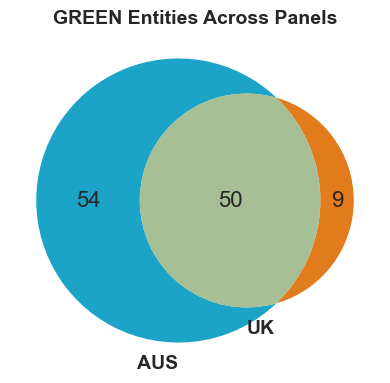

In [7]:
plot_merged_venn_diagram(panelapp_merged)
plt.tight_layout()
plt.savefig(
    f"{figures_path}/green_entities_across_panels.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [ ]:
# Save for further evaluation during gene set validation

found_status_conflicts = panelapp_merged.save_status_conflicts(dir=mid_processed_path)

if found_status_conflicts is not None:
    display(found_status_conflicts)
    display(
        pd.crosstab(
            found_status_conflicts[f"Status{panelapp_merged.suffix_left}"],
            found_status_conflicts[f"Status{panelapp_merged.suffix_right}"],
            margins=True,
        )
    )

INFO: Saving Status conflicts...
INFO: Saving Status conflicts: Done!


,Name,Status_AUS,Status_UK
0,ATP6AP2,GREEN,RED
1,ATP7B,GREEN,GRAY
2,CHCHD2,GREEN,AMBER
3,CLN3,GREEN,GRAY
4,CP,GREEN,GRAY
5,DNAJC12,GREEN,GRAY
6,DNAJC5,GREEN,GRAY
7,NR4A2,GREEN,RED
8,OPA3,RED,GREEN
9,PDE8B,GREEN,GRAY


Status_UK,GREEN,AMBER,RED,GRAY,All
Status_AUS,,,,,
GREEN,0,1,2,11,14
RED,2,0,0,0,2
All,2,1,2,11,16


In [9]:
# TODO: Explain complexities of panel harmonization

# Solve Status conflicts with default strategy
panelapp_merged.default_status_solve()

# Build consensus DataFrame
consensus_panel_df = panelapp_merged.make_consensus()

INFO: Starting default Status conflict solving strategy...
INFO: Default Status conflict solving strategy: End.
INFO: MAKE CONSENSUS START.
INFO: Copying unconflicted...
INFO: Creating new DataFrame...
INFO: MAKE CONSENSUS END.


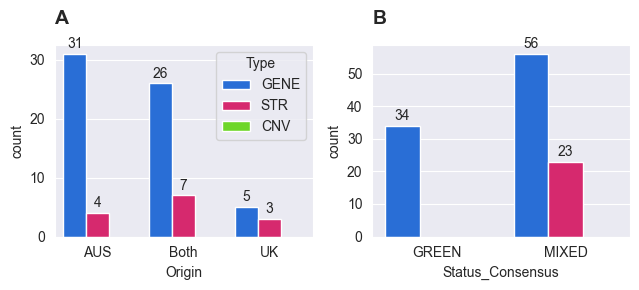

In [10]:
fig, axes = plt.subplots(ncols=2, figsize=(6.5, 3))
count_plot(consensus_panel_df, "Origin", 6.5, 3, True, axes[0])
count_plot(consensus_panel_df, "Status_Consensus", 3.25, 2.5, True, axes[1])
axes[1].get_legend().remove()
axes[0].set_title(f"A", loc="left", fontweight="bold", fontsize=14, pad=15)
axes[1].set_title(f"B", loc="left", fontweight="bold", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(
    f"{figures_path}/origin_and_consensus_counts_by_type.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

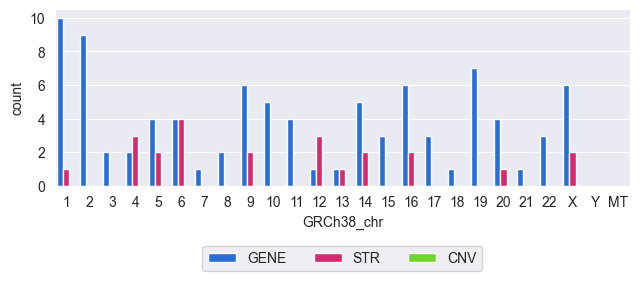

In [11]:
chromosomes_ax = count_plot(consensus_panel_df, "GRCh38_chr", 6.5, 2.5, False, ticks=2)
plt.tight_layout()
chromosomes_ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=len(chromosomes_ax.get_legend().legend_handles),  # type: ignore
)
plt.savefig(
    f"{figures_path}/chromosome_counts_by_type.png", dpi=300, bbox_inches="tight"
)
plt.show()

## Retrieve & Parse Gene RefSeq Annotations


Next steps...

- Replace Ensembl 90/10X gene annotations by RefSeq
- Create BED with GENE entities exons, STRs, and CNVs regions.
- Analysis and conclusions
